In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-07.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-06.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-11.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-05.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-04.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-09.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-08.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/Stations_2016.csv
/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2016/BixiMontrealRentals2016/OD_2016-10.csv
/kaggle/input/bixi-montreal-bikeshare-data/

In [2]:
import matplotlib.pyplot as plt
from datetime import datetime
import csv
import seaborn as sns
plt.style.use('ggplot')

In [3]:
#Import the data
bikes06=pd.read_csv('/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2019/OD_2019-06.csv')
bikes07=pd.read_csv('/kaggle/input/bixi-montreal-bikeshare-data/BixiMontrealRentals2019/OD_2019-07.csv')

In [4]:
#Join the data into one
bikes = pd.concat([bikes06, bikes07])
bikes  

,start_date,start_station_code,end_date,end_station_code,duration_sec,is_member
0,2019-06-01 00:00:03,6026,2019-06-01 00:03:20,6036,197,0
1,2019-06-01 00:00:06,6197,2019-06-01 00:24:02,6006,1436,1
2,2019-06-01 00:00:10,6435,2019-06-01 00:11:53,7082,702,1
3,2019-06-01 00:00:10,7036,2019-06-01 00:21:40,6213,1289,0
4,2019-06-01 00:00:11,7003,2019-06-01 00:12:12,6019,721,1
...,...,...,...,...,...,...
1102841,2019-07-31 23:59:43,6424,2019-08-01 00:18:33,6426,1130,1
1102842,2019-07-31 23:59:43,6020,2019-08-01 00:11:43,7020,719,1
1102843,2019-07-31 23:59:48,6906,2019-08-01 00:07:18,6362,449,0
1102844,2019-07-31 23:59:50,6248,2019-08-01 00:28:18,6330,1707,1


In [5]:
bikes.dtypes

start_date            object
start_station_code     int64
end_date              object
end_station_code       int64
duration_sec           int64
is_member              int64
dtype: object

In [6]:
#Cleaning the data
bikes['start_date'] = pd.to_datetime(bikes['start_date'], format='%Y-%m-%d %H:%M:%S')
bikes['end_date'] = pd.to_datetime(bikes['end_date'], format='%Y-%m-%d %H:%M:%S')

In [7]:
bikes.dtypes

start_date            datetime64[ns]
start_station_code             int64
end_date              datetime64[ns]
end_station_code               int64
duration_sec                   int64
is_member                      int64
dtype: object

In [8]:
#Create new column
day_of_the_week = bikes['start_date'].dt.day_name()
bikes['day_of_the_week'] = day_of_the_week

bikes['no_day_of_week'] = bikes['start_date'].dt.weekday #0 monday 6 sunday

month_name = bikes['start_date'].dt.month_name()
bikes['month_name'] = month_name

In [9]:
bikes.head(3)

,start_date,start_station_code,end_date,end_station_code,duration_sec,is_member,day_of_the_week,no_day_of_week,month_name
0,2019-06-01 00:00:03,6026,2019-06-01 00:03:20,6036,197,0,Saturday,5,June
1,2019-06-01 00:00:06,6197,2019-06-01 00:24:02,6006,1436,1,Saturday,5,June
2,2019-06-01 00:00:10,6435,2019-06-01 00:11:53,7082,702,1,Saturday,5,June


In [10]:
#Checking null values
bikes.isnull().any()

start_date            False
start_station_code    False
end_date              False
end_station_code      False
duration_sec          False
is_member             False
day_of_the_week       False
no_day_of_week        False
month_name            False
dtype: bool

In [11]:
#Checking duplicates
bikes.duplicated().sum()

156

In [12]:
#Delete duplicates
bikes = bikes.drop_duplicates()
print(len(bikes))

2036099


In [13]:
bikes.duplicated().sum()

0

In [14]:
bikes.columns

Index(['start_date', 'start_station_code', 'end_date', 'end_station_code',
       'duration_sec', 'is_member', 'day_of_the_week', 'no_day_of_week',
       'month_name'],
      dtype='object')

In [15]:
bikes.shape

(2036099, 9)

In [16]:
bikes['start_date'].value_counts()

start_date
2019-06-27 08:27:14    10
2019-07-02 17:13:10     9
2019-06-18 17:06:49     9
2019-07-16 17:39:18     9
2019-07-31 17:37:23     8
                       ..
2019-06-25 18:43:10     1
2019-06-25 18:43:09     1
2019-06-25 18:43:08     1
2019-06-25 18:43:04     1
2019-07-31 23:59:53     1
Name: count, Length: 1536336, dtype: int64

In [17]:
bikes['end_date'].value_counts()

end_date
2019-06-11 17:46:06    9
2019-06-18 08:50:43    9
2019-07-08 17:47:18    8
2019-07-08 08:49:03    8
2019-07-04 08:49:08    8
                      ..
2019-06-25 19:06:33    1
2019-06-25 19:06:37    1
2019-06-25 19:03:50    1
2019-06-25 19:11:57    1
2019-08-01 00:15:53    1
Name: count, Length: 1532065, dtype: int64

In [18]:
Total = bikes['is_member'].sum()
print(Total)

1637846


In [19]:
code_grp = bikes.groupby(['start_station_code'])
code_avg_trip = code_grp['is_member'].mean().sort_values(ascending=False)
code_avg_trip = code_avg_trip.to_frame()

code_avg_trip

,is_member
start_station_code,
6089,0.927622
6226,0.926695
6367,0.924773
6192,0.916573
7019,0.914808
...,...
7094,0.329004
6501,0.320297
6109,0.319607


In [20]:
bikes.groupby('start_station_code')['duration_sec'].mean().to_frame('avg_time')

,avg_time
start_station_code,
4000,907.620228
4001,1040.390698
4002,1215.284380
5002,1249.327068
5003,1194.319444
...,...
7146,692.207675
7147,870.470472
7148,1212.800000


In [21]:
bikes.groupby('start_station_code')['duration_sec'].sum().sort_values(ascending=False)

start_station_code
6052    17892164
6036    17706306
6026    17700328
6501    14032314
6406    12861048
          ...   
7086      150188
7088      146169
7118      133528
7089      105540
7085       51344
Name: duration_sec, Length: 617, dtype: int64

In [22]:
bikes.groupby(['start_station_code','end_station_code']).count().sum().sort_values(ascending=False)
print(bikes)

                 start_date  start_station_code            end_date  \
0       2019-06-01 00:00:03                6026 2019-06-01 00:03:20   
1       2019-06-01 00:00:06                6197 2019-06-01 00:24:02   
2       2019-06-01 00:00:10                6435 2019-06-01 00:11:53   
3       2019-06-01 00:00:10                7036 2019-06-01 00:21:40   
4       2019-06-01 00:00:11                7003 2019-06-01 00:12:12   
...                     ...                 ...                 ...   
1102841 2019-07-31 23:59:43                6424 2019-08-01 00:18:33   
1102842 2019-07-31 23:59:43                6020 2019-08-01 00:11:43   
1102843 2019-07-31 23:59:48                6906 2019-08-01 00:07:18   
1102844 2019-07-31 23:59:50                6248 2019-08-01 00:28:18   
1102845 2019-07-31 23:59:53                6233 2019-08-01 00:15:53   

         end_station_code  duration_sec  is_member day_of_the_week  \
0                    6036           197          0        Saturday   
1      

In [23]:
bikes.groupby('start_station_code')['duration_sec'].count().sort_values(ascending=False)

start_station_code
6136    15836
6052    15381
6184    15283
6100    12793
6036    12738
        ...  
7118      122
7086      121
7088       98
7089       50
7085       33
Name: duration_sec, Length: 617, dtype: int64

In [24]:
bikes.groupby('start_station_code')['duration_sec'].max().sort_values(ascending=False)

start_station_code
7062    7199
6734    7198
6742    7198
6220    7197
7017    7197
        ... 
6918    3436
6130    3280
7118    3273
7098    3125
6346    3057
Name: duration_sec, Length: 617, dtype: int64

In [25]:
bikes.groupby('end_station_code')['duration_sec'].count().sort_values(ascending=False)

end_station_code
6052    20705
6012    18533
6043    17567
6036    17545
6026    17496
        ...  
7087      139
7086      130
7088      103
7089       63
7085       26
Name: duration_sec, Length: 617, dtype: int64

In [26]:
bikes.groupby('end_station_code')['duration_sec'].max().sort_values(ascending=False)

end_station_code
7068    7199
6406    7198
6734    7198
6220    7197
6381    7197
        ... 
7113    3124
6344    3088
6264    3085
7146    2667
6192    2635
Name: duration_sec, Length: 617, dtype: int64

In [27]:
bikes.groupby('start_station_code')['duration_sec'].min().sort_values(ascending=False)

start_station_code
7085    409
7118    315
7121    238
7086    235
7089    187
       ... 
6097     61
6258     61
7013     61
7014     61
6228     61
Name: duration_sec, Length: 617, dtype: int64

In [28]:
bikes.groupby('end_station_code')['duration_sec'].median().sort_values(ascending=False)

end_station_code
7104    2208.5
7103    1983.0
7123    1825.0
7112    1698.0
7111    1688.5
         ...  
6136     402.0
6706     393.0
6263     378.0
6408     350.0
6707     346.0
Name: duration_sec, Length: 617, dtype: float64

In [29]:
bikes.groupby('is_member')['duration_sec'].count()


is_member
0     398253
1    1637846
Name: duration_sec, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

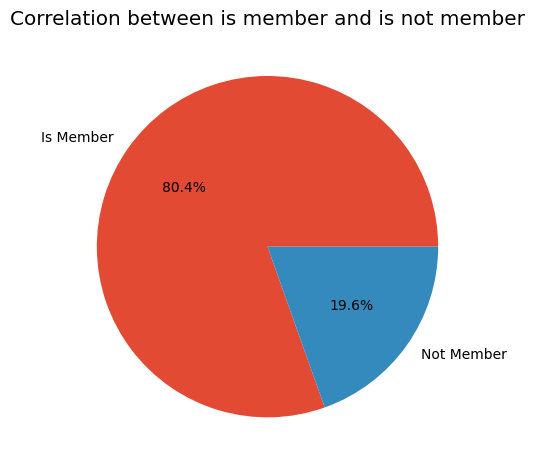

In [30]:
#Percentage 
labels = 'Is Member', 'Not Member'
sizes = [1637846,398253]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title('Correlation between is member and is not member')
plt.tight_layout()
plt.show

In [31]:
bikes.groupby('is_member').count()

,start_date,start_station_code,end_date,end_station_code,duration_sec,day_of_the_week,no_day_of_week,month_name
is_member,,,,,,,,
0,398253,398253,398253,398253,398253,398253,398253,398253
1,1637846,1637846,1637846,1637846,1637846,1637846,1637846,1637846


In [32]:
bikes.groupby('is_member')['duration_sec'].agg(['min','max'])

,min,max
is_member,,
0,61,7198
1,61,7199


In [33]:
bikes.groupby('is_member')['duration_sec'].agg(['min','max']).rename(columns = {'min':'minimum','max':'maximum'})

,minimum,maximum
is_member,,
0,61,7198
1,61,7199


In [34]:
bikes['duration_sec'].mean()

848.571854806667

In [35]:
bikes.groupby('is_member')['duration_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
is_member,,,,,,,,
0,398253.0,1200.610742,830.535232,61.0,666.0,1046.0,1500.0,7198.0
1,1637846.0,762.971290,557.430005,61.0,354.0,612.0,1025.0,7199.0


<function matplotlib.pyplot.show(close=None, block=None)>

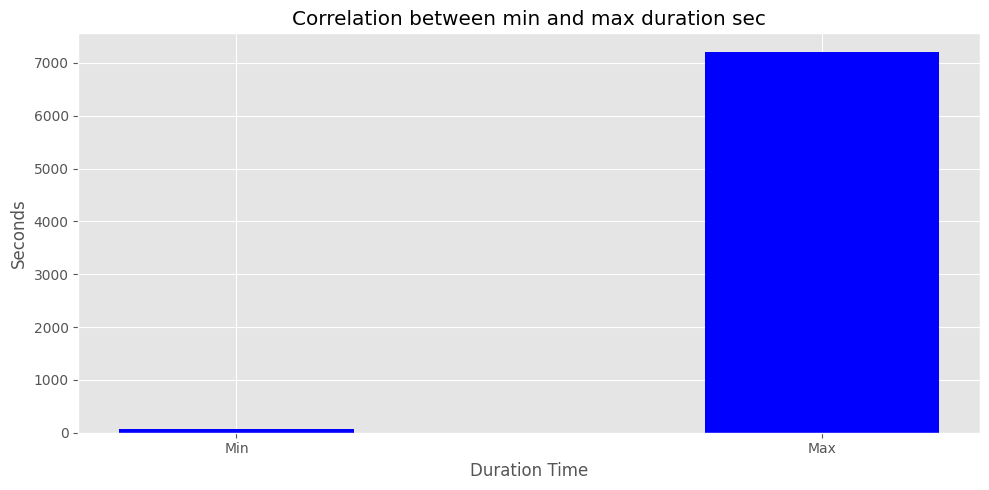

In [36]:
data = {'Min':61, 'Max': 7199}
courses = list(data.keys())
values = list(data.values())
  
fig = plt.figure(figsize = (10, 5))
 
# creating the bar plot
plt.bar(courses, values, color ='blue', 
        width = 0.4)
 
plt.xlabel("Duration Time")
plt.ylabel("Seconds")
plt.title('Correlation between min and max duration sec')
plt.tight_layout()
plt.show

In [37]:
bikes.describe()

,start_date,start_station_code,end_date,end_station_code,duration_sec,is_member,no_day_of_week
count,2036099,2.036099e+06,2036099,2.036099e+06,2.036099e+06,2.036099e+06,2.036099e+06
mean,2019-07-02 17:24:13.615498240,6.377810e+03,2019-07-02 17:38:22.686618112,6.378354e+03,8.485719e+02,8.044039e-01,2.888540e+00
min,2019-06-01 00:00:03,4.000000e+03,2019-06-01 00:03:20,4.000000e+03,6.100000e+01,0.000000e+00,0.000000e+00
25%,2019-06-17 19:11:01.500000,6.125000e+03,2019-06-17 19:25:24,6.109000e+03,3.920000e+02,1.000000e+00,1.000000e+00
50%,2019-07-03 11:50:36,6.221000e+03,2019-07-03 12:04:11,6.220000e+03,6.870000e+02,1.000000e+00,3.000000e+00
75%,2019-07-17 19:46:28.500000,6.501000e+03,2019-07-17 20:00:40.500000,6.503000e+03,1.143000e+03,1.000000e+00,5.000000e+00
max,2019-07-31 23:59:53,1.000200e+04,2019-08-01 01:08:51,1.000200e+04,7.199000e+03,1.000000e+00,6.000000e+00
std,NaN,4.209397e+02,NaN,4.335527e+02,6.442091e+02,3.966590e-01,1.982210e+00


<function matplotlib.pyplot.show(close=None, block=None)>

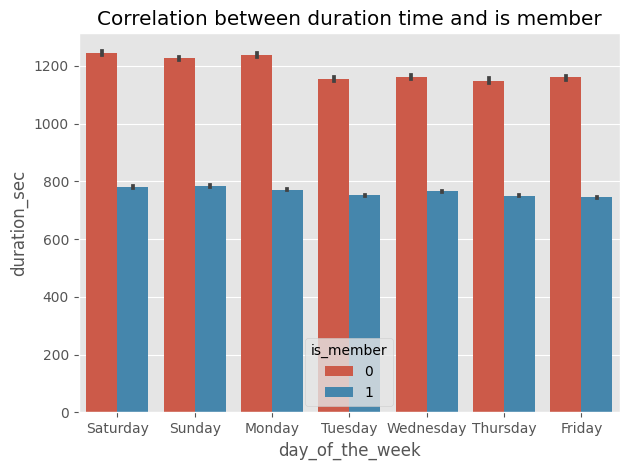

In [38]:
#Correlation between duration time and is member
ax = sns.barplot(x='day_of_the_week', y='duration_sec',data=bikes, hue=bikes['is_member'])

plt.title('Correlation between duration time and is member')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

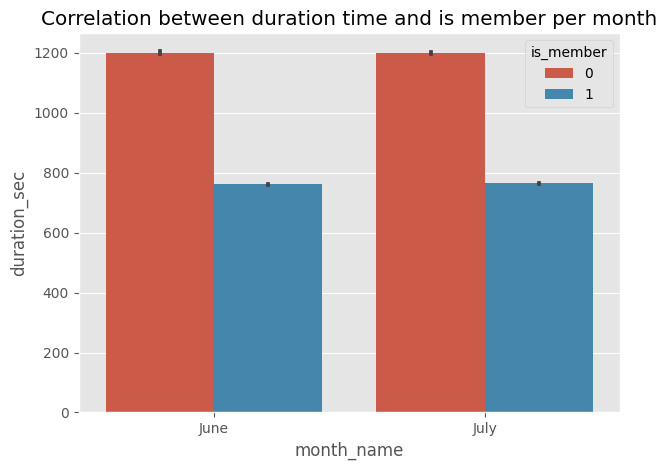

In [39]:
#Correlation between duration time and is member per month
ax = sns.barplot(x='month_name', y='duration_sec',data=bikes, hue=bikes['is_member'])

plt.title('Correlation between duration time and is member per month')
plt.tight_layout()
plt.show